# exp-gs-002-14 — fixed three-way LR probability ensemble

13번까지 통과한 모델만 고정 비율로 결합한다. 새 피처·파라미터·가중치 탐색은 하지 않는다.

- 08 primary LR: `0.50`
- event-token TF-IDF multinomial LR: `0.25`
- event-token TF-IDF OVR LR: `0.25`

비교 기준은 13번 primary+OVR 0.5/0.5 앙상블이다. OOF에서는 train.csv만 읽고 fold-train으로만 feature matrix·vocabulary·IDF·모델을 fit한다. WT와 NaN은 mutation token이 아니며 test 데이터·test 통계를 사용하지 않는다.

고정: `C=0.07`, `max_iter=2000`, `class_weight='balanced'`, Stratified 5-fold, seeds `42/2024/777`, `min_df=3`, `sublinear_tf=True`. 결과에 따라 가중치·min_df·피처·모델 파라미터를 재탐색하지 않는다.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp-gs-002-memory-safe.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('eda_pre_002 실행기를 찾지 못했습니다.')

EDA_DIR = find_eda_dir()
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'
RESULT_DIR.mkdir(exist_ok=True)
RUN_ID = 'exp-gs-002-14'
CANDIDATE = 'H-AS-LR-exact-confusion-pairs-Apair-log1p'
SEEDS = (42, 2024, 777)
MIN_DF = 3
WEIGHTS = {'primary': 0.50, 'multinomial': 0.25, 'ovr': 0.25}
RUN_EXPERIMENT = True
OOF_TRAIN_ONLY = True
assert sum(WEIGHTS.values()) == 1.0
print({'runner': RUNNER, 'seeds': SEEDS, 'weights': WEIGHTS, 'min_df': MIN_DF, 'oof_train_only': OOF_TRAIN_ONLY})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'seeds': (42, 2024, 777), 'weights': {'primary': 0.5, 'multinomial': 0.25, 'ovr': 0.25}, 'min_df': 3, 'oof_train_only': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='14 | fixed 3-way LR ensemble | OOF', unit='seed'):
        subprocess.run([
            sys.executable, str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', CANDIDATE,
            '--seed', str(seed),
            '--event-tfidf-three-way',
            '--tfidf-min-df', str(MIN_DF),
        ], check=True)
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.59it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 42: 100%|██████████| 5/5 [03:24<00:00, 40.93s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.47814168846488037,
  "event_tfidf_multinomial_oof_macro_f1": 0.3782884640237529,
  "event_tfidf_ovr_oof_macro_f1": 0.47614610334900986,
  "blend_multinomial_0p5_oof_macro_f1": 0.4794557135599829,
  "blend_ovr_0p5_oof_macro_f1": 0.4834703526083619,
  "blend_three_way_0p5_0p25_0p25_oof_macro_f1": 0.48166267385898454,
  "delta_ovr_blend_vs_multinomial_blend": 0.0040146390483790095,
  "delta_three_way_vs_ovr_blend": -0.0018076787493773727,
  "primary_oof_accuracy": 0.45879696823093047,
  "event_tfidf_multinomial_oof_accuracy": 0.3971940009675859,
  "event_tfidf_ovr_oof_accuracy": 0.4578293823576842,
  "blend_multinomial_0p5_oof_accuracy": 0.45992581841638447,
  "blend_ovr_0p5_oof_accuracy": 0.46234478309950006,
  "blend_three_way_0p5_0p25_0p25_oof_accuracy": 0.4610546686018384,
  "token_prediction_disagreement_

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 399.63it/s]/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 2024: 100%|██████████| 5/5 [03:25<00:00, 41.11s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.4762175133106753,
  "event_tfidf_multinomial_oof_macro_f1": 0.37834570023612246,
  "event_tfidf_ovr_oof_macro_f1": 0.48209401153092346,
  "blend_multinomial_0p5_oof_macro_f1": 0.4770919206532897,
  "blend_ovr_0p5_oof_macro_f1": 0.4803383399998615,
  "blend_three_way_0p5_0p25_0p25_oof_macro_f1": 0.4795235940320009,
  "delta_ovr_blend_vs_multinomial_blend": 0.0032464193465717717,
  "delta_three_way_vs_ovr_blend": -0.0008147459678605751,
  "primary_oof_accuracy": 0.4594420254797613,
  "event_tfidf_multinomial_oof_accuracy": 0.397677793904209,
  "event_tfidf_ovr_oof_accuracy": 0.46040961135300756,
  "blend_multinomial_0p5_oof_accuracy": 0.4591194968553459,
  "blend_ovr_0p5_oof_accuracy": 0.46169972585066926,
  "blend_three_way_0p5_0p25_0p25_oof_accuracy": 0.4612159329140461,
  "token_prediction_disagreement_r

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 394.62it/s]/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | TF-IDF multinomial vs OVR | seed 777: 100%|██████████| 5/5 [03:12<00:00, 38.42s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 777,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.481145738774279,
  "event_tfidf_multinomial_oof_macro_f1": 0.3705716160280971,
  "event_tfidf_ovr_oof_macro_f1": 0.4735678213237862,
  "blend_multinomial_0p5_oof_macro_f1": 0.48436600336351787,
  "blend_ovr_0p5_oof_macro_f1": 0.4855817039961349,
  "blend_three_way_0p5_0p25_0p25_oof_macro_f1": 0.4843720215555108,
  "delta_ovr_blend_vs_multinomial_blend": 0.0012157006326170006,
  "delta_three_way_vs_ovr_blend": -0.0012096824406240825,
  "primary_oof_accuracy": 0.4613771972262538,
  "event_tfidf_multinomial_oof_accuracy": 0.39138848572810836,
  "event_tfidf_ovr_oof_accuracy": 0.4565392678600226,
  "blend_multinomial_0p5_oof_accuracy": 0.46411869053378485,
  "blend_ovr_0p5_oof_accuracy": 0.4628285760361232,
  "blend_three_way_0p5_0p25_0p25_oof_accuracy": 0.46363489759716175,
  "token_prediction_disagreement_ra

14 | fixed 3-way LR ensemble | OOF: 100%|██████████| 3/3 [11:14<00:00, 225.00s/seed]


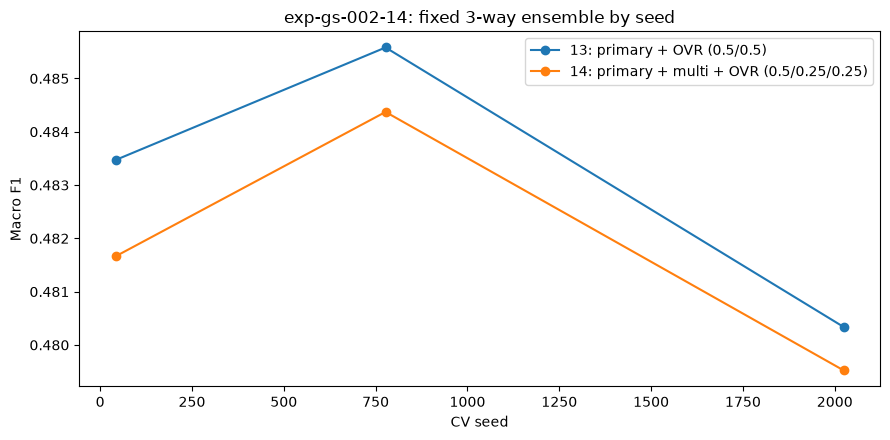

,experiment_id,model,seed,tfidf_min_df,tfidf_sublinear_tf,primary_oof_macro_f1,event_tfidf_multinomial_oof_macro_f1,event_tfidf_ovr_oof_macro_f1,blend_multinomial_0p5_oof_macro_f1,blend_ovr_0p5_oof_macro_f1,...,token_prediction_disagreement_rate,feature_count_mean,tfidf_vocabulary_size_mean,runtime_seconds,primary_convergence_warning_count,tfidf_multinomial_convergence_warning_count,tfidf_ovr_convergence_warning_count,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,42,3,True,0.478142,0.378288,0.476146,0.479456,0.483470,...,0.407676,8175.2,5875.8,205.011706,0,0,0,0,True,0
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,777,3,True,0.481146,0.370572,0.473568,0.484366,0.485582,...,0.411385,8170.4,5869.6,192.443917,0,0,0,0,True,0
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,2024,3,True,0.476218,0.378346,0.482094,0.477092,0.480338,...,0.412353,8175.0,5868.4,203.855958,0,0,0,0,True,0


,experiment_id,seed_count,weights,ovr_blend_macro_f1_mean,ovr_blend_macro_f1_std,three_way_macro_f1_mean,three_way_macro_f1_std,delta_three_way_vs_ovr_mean,delta_three_way_vs_ovr_std,all_seed_three_way_delta_positive,feature_count_mean,tfidf_vocabulary_size_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,exp-gs-002-14,3,"primary=0.50,multinomial=0.25,ovr=0.25",0.48313,0.002638,0.481853,0.00243,-0.001277,0.0005,False,8173.533333,5871.266667,0,True,0


In [3]:
def result_path(seed, suffix):
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_event-tfidf-three-way_seed{seed}_{suffix}.csv'

oof_files = [result_path(seed, 'oof') for seed in SEEDS]
missing = [path for path in oof_files if not path.exists()]
if missing:
    raise FileNotFoundError('누락 결과 파일:\n' + '\n'.join(map(str, missing)))

per_seed = pd.concat([pd.read_csv(path) for path in oof_files], ignore_index=True).sort_values('seed')
assert per_seed['leakage_check'].all()
assert per_seed['nan_as_mutation_count'].eq(0).all()
assert per_seed['tfidf_min_df'].eq(MIN_DF).all()

baseline_column = 'blend_ovr_0p5_oof_macro_f1'
three_way_column = 'blend_three_way_0p5_0p25_0p25_oof_macro_f1'
summary = pd.DataFrame([{
    'experiment_id': RUN_ID,
    'seed_count': len(SEEDS),
    'weights': 'primary=0.50,multinomial=0.25,ovr=0.25',
    'ovr_blend_macro_f1_mean': per_seed[baseline_column].mean(),
    'ovr_blend_macro_f1_std': per_seed[baseline_column].std(),
    'three_way_macro_f1_mean': per_seed[three_way_column].mean(),
    'three_way_macro_f1_std': per_seed[three_way_column].std(),
    'delta_three_way_vs_ovr_mean': per_seed['delta_three_way_vs_ovr_blend'].mean(),
    'delta_three_way_vs_ovr_std': per_seed['delta_three_way_vs_ovr_blend'].std(),
    'all_seed_three_way_delta_positive': bool(per_seed['delta_three_way_vs_ovr_blend'].gt(0).all()),
    'feature_count_mean': per_seed['feature_count_mean'].mean(),
    'tfidf_vocabulary_size_mean': per_seed['tfidf_vocabulary_size_mean'].mean(),
    'convergence_warning_count': int(per_seed['convergence_warning_count'].sum()),
    'leakage_check': bool(per_seed['leakage_check'].all()),
    'nan_as_mutation_count': int(per_seed['nan_as_mutation_count'].sum()),
}])

class_seed = pd.concat([pd.read_csv(result_path(seed, 'class_f1')).assign(seed=seed) for seed in SEEDS], ignore_index=True)
class_summary = class_seed.groupby(['variant', 'class'], as_index=False).agg(class_f1_mean=('f1-score', 'mean'), class_f1_std=('f1-score', 'std'), support=('support', 'first'))
per_seed.to_csv(RESULT_DIR / 'exp-gs-002-14_per_seed.csv', index=False)
summary.to_csv(RESULT_DIR / 'exp-gs-002-14_summary.csv', index=False)
class_summary.to_csv(RESULT_DIR / 'exp-gs-002-14_class_f1_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
for column, label in [(baseline_column, '13: primary + OVR (0.5/0.5)'), (three_way_column, '14: primary + multi + OVR (0.5/0.25/0.25)')]:
    ax.plot(per_seed['seed'], per_seed[column], marker='o', label=label)
ax.set(title='exp-gs-002-14: fixed 3-way ensemble by seed', xlabel='CV seed', ylabel='Macro F1')
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / 'exp-gs-002-14_oof_macro_f1.png', dpi=160, bbox_inches='tight')
plt.show()
display(per_seed)
display(summary)